<a href="https://colab.research.google.com/github/AnkushSharmaGuragai/AI-ML/blob/main/WorksheetAI_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/Data/Copy of devnagari digit.zip'
data_path = '/content/drive/MyDrive/AI ML/Data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/AI ML/Data/Copy of devnagari digit.zip' to '/content/drive/MyDrive/AI ML'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [ ]:
train_dir = "/content/drive/MyDrive/AI ML/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/AI ML/DevanagariHandwrittenDigitDataset/Test"
img_height, img_width = 28, 28
num_classes = 10

load and preprocess dataset


In [ ]:
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))

    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [ ]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


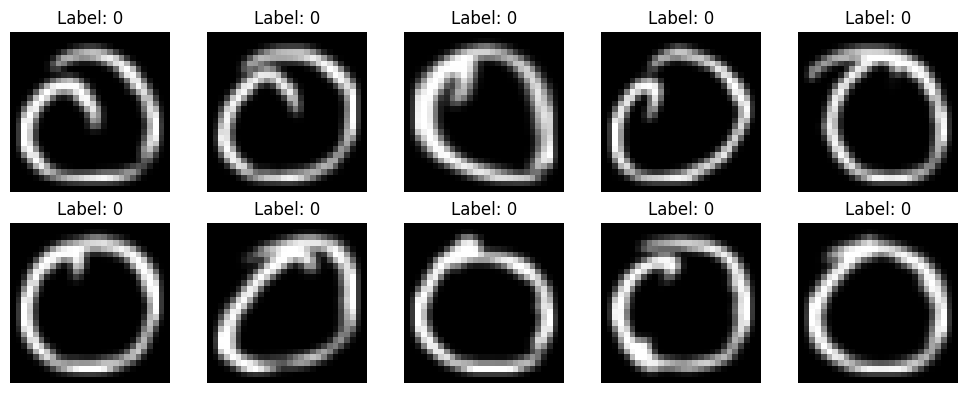

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

shuffle and split training/validation

In [ ]:
x_train, y_train = shuffle(x_train, y_train, random_state=42)


x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42

)

print(f"Training   : {x_train_final.shape}")
print(f"Validation : {x_val.shape}")
print(f"Testing    : {x_test.shape}")

Training   : (13600, 28, 28, 1)
Validation : (3400, 28, 28, 1)
Testing    : (3000, 28, 28, 1)


build FCN model

In [ ]:

input_shape = (28, 28, 1)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax")
])



compile model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks


In [ ]:
callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/AI ML/Data/devnagari_model.h5",
        save_best_only=True
    ),


    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

train model

In [ ]:


history = model.fit(
    x_train_final,
    y_train_final,
    batch_size=128,
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2186 - loss: 2.2101

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3879 - loss: 1.9045 - val_accuracy: 0.6985 - val_loss: 1.1351
Epoch 2/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7501 - loss: 0.9177

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7934 - loss: 0.7289 - val_accuracy: 0.8553 - val_loss: 0.4737
Epoch 3/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8739 - loss: 0.4222

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8871 - loss: 0.3788 - val_accuracy: 0.8903 - val_loss: 0.3243
Epoch 4/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9139 - loss: 0.2870

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9266 - loss: 0.2551 - val_accuracy: 0.9315 - val_loss: 0.2367
Epoch 5/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9413 - loss: 0.2073

...

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9938 - loss: 0.0300 - val_accuracy: 0.9732 - val_loss: 0.0902
Epoch 16/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9957 - loss: 0.0245

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9955 - loss: 0.0252 - val_accuracy: 0.9729 - val_loss: 0.0867
Epoch 17/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9972 - loss: 0.0219

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9973 - loss: 0.0209 - val_accuracy: 0.9747 - val_loss: 0.0860
Epoch 18/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9978 - loss: 0.0162

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9977 - loss: 0.0172 - val_accuracy: 0.9759 - val_loss: 0.0847
Epoch 19/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9989 - loss: 0.0131

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9984 - loss: 0.0144 - val_accuracy: 0.9762 - val_loss: 0.0818
Epoch 20/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9989 - loss: 0.0121 - val_accuracy: 0.9762 - val_loss: 0.0855


Evaluate current model

In [ ]:
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=2)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Test Loss           : {test_loss:.4f}")



107/107 - 0s - 3ms/step - accuracy: 0.9762 - loss: 0.0818
94/94 - 0s - 2ms/step - accuracy: 0.9800 - loss: 0.0771
Validation Accuracy : 0.9762
Validation Loss     : 0.0818
Test Accuracy       : 0.9800
Test Loss           : 0.0771


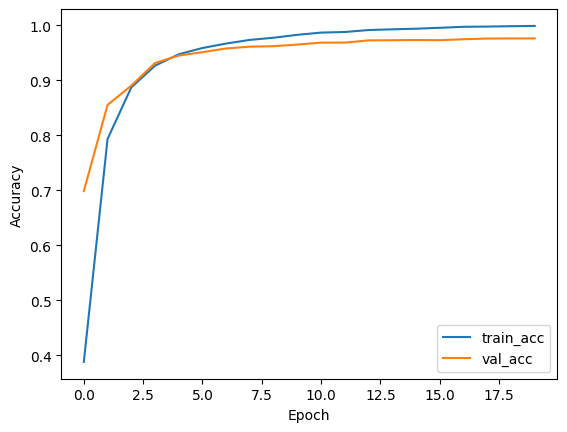

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

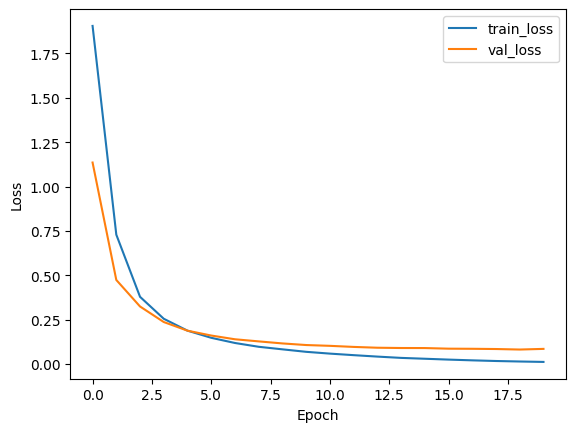

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

save model

In [ ]:
model.save("/content/drive/MyDrive/AI ML/Data/devnagari_model.h5")
print("Model saved as devnagari_model.h5")

Model saved as devnagari_model.h5


load model

In [ ]:
loaded_model = load_model("/content/drive/MyDrive/AI ML/Data/devnagari_model.h5")
print("Model loaded successfully")

Model loaded successfully


evaluate loaded model

In [ ]:
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"Loaded Model Test Accuracy : {loaded_test_acc:.4f}")
print(f"Loaded Model Test Loss     : {loaded_test_loss:.4f}")

94/94 - 1s - 9ms/step - accuracy: 0.9800 - loss: 0.0771
Loaded Model Test Accuracy : 0.9800
Loaded Model Test Loss     : 0.0771


predictions

In [ ]:
x_test, y_test = shuffle(x_test, y_test, random_state=42)

y_pred_probs = loaded_model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print("First 10 predictions:", y_pred_labels[:10])
print("First 10 true labels:", y_true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
First 10 predictions: [6 3 6 0 8 3 4 7 1 8]
First 10 true labels: [6 3 6 0 8 3 4 7 1 8]
